In [2]:
!cd '/Users/scsaalt/Library/CloudStorage/OneDrive-UniversityofLeeds/MScAIODLResources/RLandRobotics/1. Reinforcement Learning and Robotics/rl_rob' && git add -A && git commit -m "update" && git push origin main
%cd ~/rl_rob 
!git pull

On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
/Users/scsaalt/rl_rob
^C


In [1]:
from rl.linear import *
from rl.neural import *

In this worksheet we will focus on training multi-layer neural networks. But first let us start by training a simple linear model. 

We have developed a strong neural network machinery, but we can simply stripp off everythign and just use the last layer (value head) in the same sense to what we did for a linear cases. 

This has two advantages, first we try to see if everything is working as expected. It is also clealry show that a linear funciton apparomiator is just a special case of a neurla netowrks. This has the advantage of behaviour of the model and algorithm that we are familir with which provide a great testing and debugging tool, in the smae sense to what we did when we moved from tabular to linear funciton approximaiotn. In fact we we use just a binary features we would be using a neural networks as an equivelnt for tabular RL. 

## Neural MC
Below we show the nnMC method implementation. 

In [37]:
class nnMC(nnMRP):
    
    # at the start of the run
    def init(self):
        self.nbuffer = self.max_t # all nnMRP and subclasses stores 
        
    # at the start of the episode
    def step0(self):
        self.buffer.clear() # clear the buffer after each episode for MC style retrieval of history
    # --------------- 🌘 offline, MC learning: end-of-episode learning ----------------  
    def offline(self):
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s, _, rn, _, _ = self.buffer[t]
            Gt = self.γ*Gt + rn
            Vs  = self.w(s)
            self.w.fit(Vs, Gt)          # let backdropagaiton handle the learning of multi-layer model
            

In [28]:
nnmc = nnMC(env=vrandwalk(), max_t=1000, α=3e-2, γ=1, seed=1, episodes=30, **demoE)

------------------- 易  nnMC is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰───────────────────────────────────────────────────────────────────────────────────────╯
Total parameters: 7 of which 0 are bias


CPU times: user 9.75 s, sys: 2.05 s, total: 11.8 s
Wall time: 5.02 s


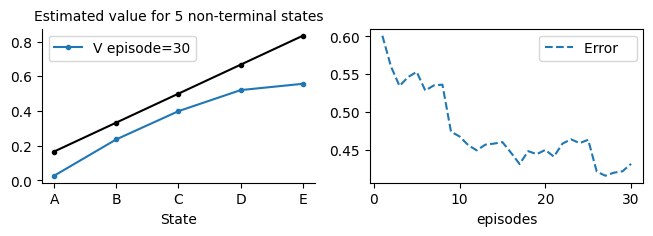

In [26]:
%time nnmc.interact()

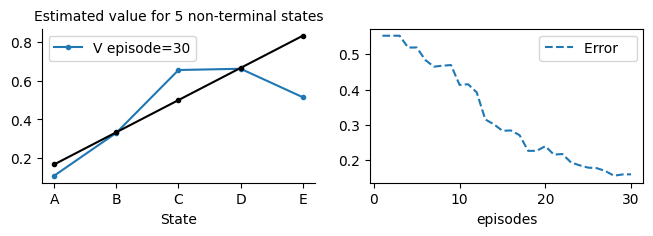

In [8]:
vmc = vMC(env=vrandwalk(), max_t=1000, α=3e-2, γ=1, seed=1, episodes=30, **demoE).interact()

## Neural TD Algorihtm
Ok, now let us develop our nerual network based semi gradient TD algorithm:

In [38]:
class nnTD(nnMRP):
    # ----------------------------- 🌖 online learning ------------------------------
    def online(self, *args):
        (s, _, rn, sn, done),_ =  self.batch(-1) # take the last sample from the buffer
        
        Vs  = self.w(s)
        Vn  = self.w(sn).detach()                # detach ensures semi-gradient
        Vn[done] = 0                             # = (1-done)*V(sn)
        
        self.w.fit(Vs, self.γ*Vn + rn)           # backprop handels multi-layer learning


In [10]:
nntd = nnTD(env=vrandwalk(), α=1e-1, γ=1,seed=1, episodes=100, **demoE)

------------------- 易  nnTD is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰───────────────────────────────────────────────────────────────────────────────────────╯
Total parameters: 7 of which 0 are bias


As we can see we have created a simple one layer neural network which is equivalent to what we have been dealing with in our previous unit. We will train this to ensure everything is working as expected.

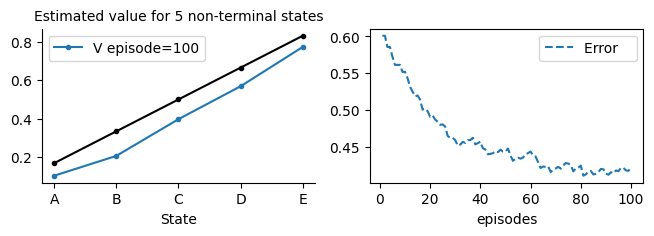

In [11]:
nntd.interact()

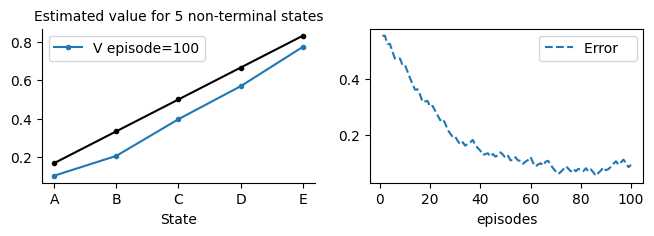

In [12]:
vtd = vTD(env=vrandwalk(), α=1e-1, γ=1,seed=1, episodes=100, **demoE).interact()

## Learning from pixles
Now we turn into a more significant learning excercise which is what we created our network infra structure for, which is training a nerual network with multi-layers. We will actually learn from pixles of states coming from our usual environments. This time the env is actually generating images of the grid as a state.

(1, 50, 84)

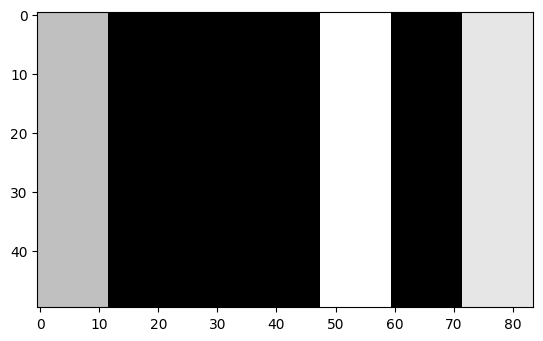

In [13]:
def irandwalk(**kw):  
    return randwalk(iGrid, **kw)

env = irandwalk()
img = env.reset()
img,_,_,_,_= env.step(1)

plt.imshow(img[0], cmap='gray')

env = imaze(reward='sparse')
env.reset().shape


## Neural Infrastructure: The Trunk and the Neck

We ave provided you with an ready made, easily configurable neural network infrastructure that can be utilise directly to create a powerful neural network models. It is based on pytorch. The model can be configured via the trunk and the neck. Remmebr that the state value function V is always a one vlaue, while ation value function Q has nA output if teh aciton space is discrete or if the action space is continuous but has multiple nA componenets. For simplicity now let us assume the aciton space is discrete.

The **trunk** is the feature extraction part of the network and can have **multiple layers**. To set the trunk we pass a list. The list can be a mix of tuples for each convolutional (c,kxk,s) layers and values for fully connected layers. The (c,kxk,s) stands for channels, kernels and stride. The trunk is essential to be able to deal with general input without having to hand encode it as we did in the previous unit via tile coding and discretisation.

So, for example if we pass trunk=[(8, 4, 2), (4, 4, 4)], that means create two Conv layers, the first produces 8 channels by convolving 4x4 kernel and striding by 2 pixles, while the second Conv layer produces 4 channels by convolving 4x4 and striding by 4. The trunk always ends with a flatten layer that flatten the output of its last layer.

There final elment to specify is the **neck**, which is the **single penultimate layer** connecting the trunk to the value head. There is fully connection between the trunk and the neck and full conneciton between the neck and the value head. This layer has nF number of final features that are going to be fully connected with value head or the action-value head. This is similar to what we have been dealing with in the linear case where nF is fully connected to the value (1d vector) or to the actions (2d array of nFxnA). 

In our previous example swhere we did not specified any trunk, that meant that there was no trunk and no nF. The input was he state representation vector which is of size nS coming directly fro the env as we saw earlier for the different venv covered before. This effectively gave us nF=nS representation that we are used to.

Ok now we are ready to train from the pixles.


In [14]:
env = irandwalk() # provides images as states
nntd = nnTD(env=env, α=2e-4, γ=1, seed=1, episodes=120, **demoE,
          trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS) # the trunk is the feature extraction part of the network

------------------- 易  nnTD is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Conv2d (4x4x1x8+8)        │ (8, 24, 41)     │        136 (  8 bias)   │ Yes      │
│  1 │ Conv2d (4x4x8x4+4)        │ (4, 6, 10)      │        516 (  4 bias)   │ Yes      │
│  2 │ Flatten                   │ (240,)          │          0 (  0 bias)   │ No       │
│  3 │ Linear (240x7)            │ (7,)            │      1,687 (  7 bias)   │ Yes      │
│  4 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰───────────────────────────────

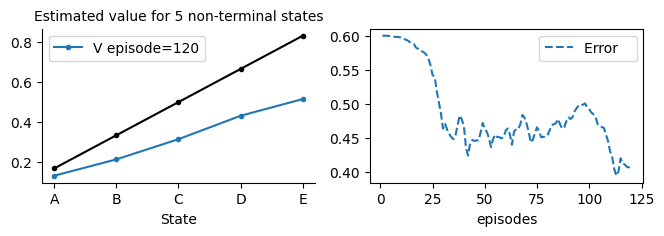

In [15]:
nntd.interact()

Increase the number of episodes and observe the behaviour of the algorithm. 

## Stochastic and Batch Learning
As can be see, the model is harder to train when we have ellaborate architecture with trunk and neck. In particular, stochastisity of the states becomes more prominant and we need to compensate for that by taking more than one stpe into account when we change the weights. This is where batch training enters the scene. As we have seen in previous modules, Ml models always benefited from batch training, in fact batch training is the norm and training via one sampel at a time is much harder for big models such as neural networks and it is more prone to high variance and overfitting. To solve this issue we can take a batch of updates for multiple steps and we apply them to stabilise training. However, this is might not be always possible as we are dealing here with sequential data, and unless the algorithm updates are built to accomodate such batching, it is not always peremisble in RL. For example, if the method is on-policy batching old samples is not perisble as it will corrupt the learning done, but we can batch a set of samples, before we do any update (so as to keep the policy the same) from the current policy and then apply their update in a batch mode. For off-policy methods such Q learning, we can actually replay any previous trajectory update since the method is built to learn about a policy that is diffrent from the behaviour policy, so for it learning from samples collected from an old version of its own policy is fine.

## Neural TD with Batch Taining
In neural networks we can train multiple steps at the same time via batch training. 
This ability it trns out to be crucial particualrly when we deal with the deadly triad to stabilise the learning by replaying old trajectories in mini batches. Below we show you a TD methd that use multiple trajectories to batch train its value function. 

In [15]:
class TDN(nnMRP):
    # ----------------------------- 🌖 online learning ----------------------  
    def online(self, *args):
        if len(self.buffer) < self.nbatch: return  # wait until we have nbatch entries in the buffer
        (s, _, rn, sn, dones), _ = self.batch() # note that we are taking a batch now instead of one buffer item
        
        Vs  = self.w(s)
        Vn  = self.w(sn).detach()
        Vn[dones] = 0
        
        self.w.fit(Vs, self.γ * Vn + rn.unsqueeze(1))

Let us now train with multiple time steps trajectoreis stored in the buffer

In [16]:
env = irandwalk()
tdn = TDN(env=env, α=2e-4, γ=1, seed=1, episodes=100, **demoE,
          trunk=[(8, 4, 2), (4, 4, 4)], nF=env.nS,
          nbuffer=100, nbatch=16, rndbatch=True)

------------------- 易  TDN is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Conv2d (4x4x1x8+8)        │ (8, 24, 41)     │        136 (  8 bias)   │ Yes      │
│  1 │ Conv2d (4x4x8x4+4)        │ (4, 6, 10)      │        516 (  4 bias)   │ Yes      │
│  2 │ Flatten                   │ (240,)          │          0 (  0 bias)   │ No       │
│  3 │ Linear (240x7)            │ (7,)            │      1,687 (  7 bias)   │ Yes      │
│  4 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰────────────────────────────────

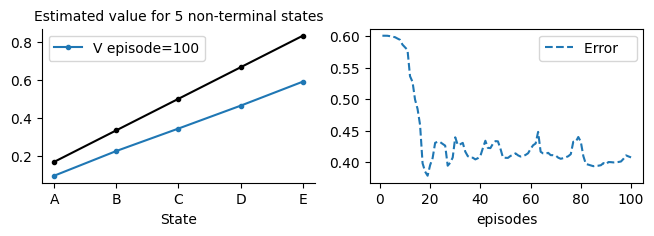

In [17]:
tdn.interact()

Note how the method behaviour changed where it converge quicker and its behaviour is more stable. Note also that the method does not start to have visible changes until around 15 episodes until the buffer is filled and the random sampling taken from the buffer is becoming more effective.

Change the learnign rate and the trunk and neck architecture and observe the effect.

So we are learning from the **pixels of the random walk** NOT directly from the states.

Note how the learning is more stable.

Change the nbuffer size and the nbatch and observe the effect. This will give you a clear idea of the effect of the these hyperparameters. These are important for any neural network solution.

In [63]:
mc = nnMC(env=vrandwalk(), α=.05, γ=1, episodes=100)
td = nnTD(env=vrandwalk(), α=.3, γ=1, episodes=100)

------------------- 易  nnMC is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬───────────────────────────┬─────────────────┬─────────────────────────┬──────────┤
│ Id │ Layer                     │ Output Shape    │ Parameters              │Trainable │
├────┼───────────────────────────┼─────────────────┼─────────────────────────┼──────────┤
│  0 │ Linear (7x1)              │ (1,)            │          7 (  0 bias)   │ Yes      │
╰───────────────────────────────────────────────────────────────────────────────────────╯
Total parameters: 7 of which 0 are bias
------------------- 易  nnTD is being set up 易 ---------------------
╭───────────────────────────────────────────────────────────────────────────────────────╮
│          Model Architecture: V                                                        │
├────┬────────

100%|██████████████████████████████████████████████████████████████████████████████████████████|10/10
100%|██████████████████████████████████████████████████████████████████████████████████████████|10/10


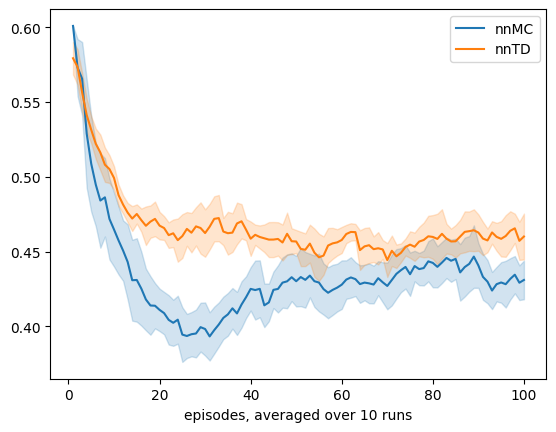

In [64]:
Runs(algorithm=mc, plotE=True, runs=10).interact(label='nnMC')
Runs(algorithm=td, plotE=True, runs=10).interact(label='nnTD')


### Conclusion
In this worksheet, we have a full neural network code based and show case how to establish well known methods from it such as DQN and Doubel DQN. These new set of methods can be used to train an agent on the pixles as input or any other type of input.